In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
path = kagglehub.dataset_download('hernan4444/anime-recommendation-database-2020')

print(os.listdir(path))
csv_path = os.path.join(path, 'anime_with_synopsis.csv')
df = pd.read_csv(csv_path)

['html folder', 'watching_status.csv', 'rating_complete.csv', 'animelist.csv', 'anime.csv', 'anime_with_synopsis.csv']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16214 entries, 0 to 16213
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MAL_ID     16214 non-null  int64 
 1   Name       16214 non-null  object
 2   Score      16214 non-null  object
 3   Genres     16214 non-null  object
 4   sypnopsis  16206 non-null  object
dtypes: int64(1), object(4)
memory usage: 633.5+ KB


In [11]:
df.describe(include='all')

,MAL_ID,Name,Score,Genres,sypnopsis
count,16214.000000,16214,16214,16214,16206
unique,NaN,16210,532,4857,15221
top,NaN,Maou Gakuin no Futekigousha: Shijou Saikyou no...,Unknown,Music,No synopsis information has been added to this...
freq,NaN,3,5123,790,709
mean,22069.271555,NaN,NaN,NaN,NaN
std,14849.798248,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,6728.500000,NaN,NaN,NaN,NaN
50%,24164.000000,NaN,NaN,NaN,NaN
75%,35978.750000,NaN,NaN,NaN,NaN


In [12]:
missing_values = df.isnull().sum()
print(missing_values[missing_values>0])
df = df.dropna()
missing_values = df.isnull().sum()
missing_values[missing_values>0]

sypnopsis    8
dtype: int64


Series([], dtype: int64)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop(columns=['MAL_ID'])
df.head()

,Name,Score,Genres,sypnopsis
0,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [15]:
df['Score'].value_counts()

Score
Unknown    5116
6.45         65
6.31         64
6.52         63
6.48         61
           ... 
4.34          1
8.88          1
9.17          1
3.89          1
4.06          1
Name: count, Length: 532, dtype: int64

In [16]:
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
median = df['Score'].median()
df['Score'] = df['Score'].replace(np.nan, median )
df['Score'].value_counts()

Score
6.57    5150
6.45      65
6.31      64
6.52      63
6.48      61
        ... 
2.66       1
4.34       1
9.17       1
3.89       1
4.06       1
Name: count, Length: 531, dtype: int64

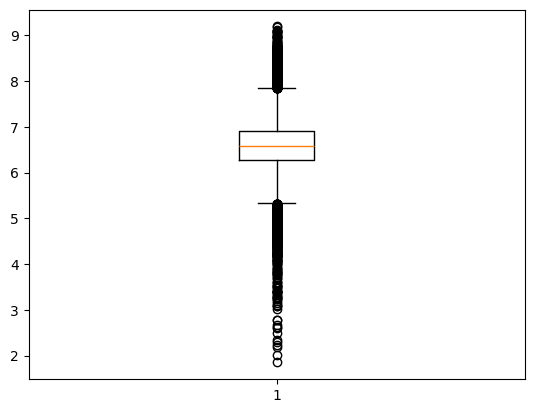

In [17]:
plt.boxplot(x=df['Score'])
plt.show()

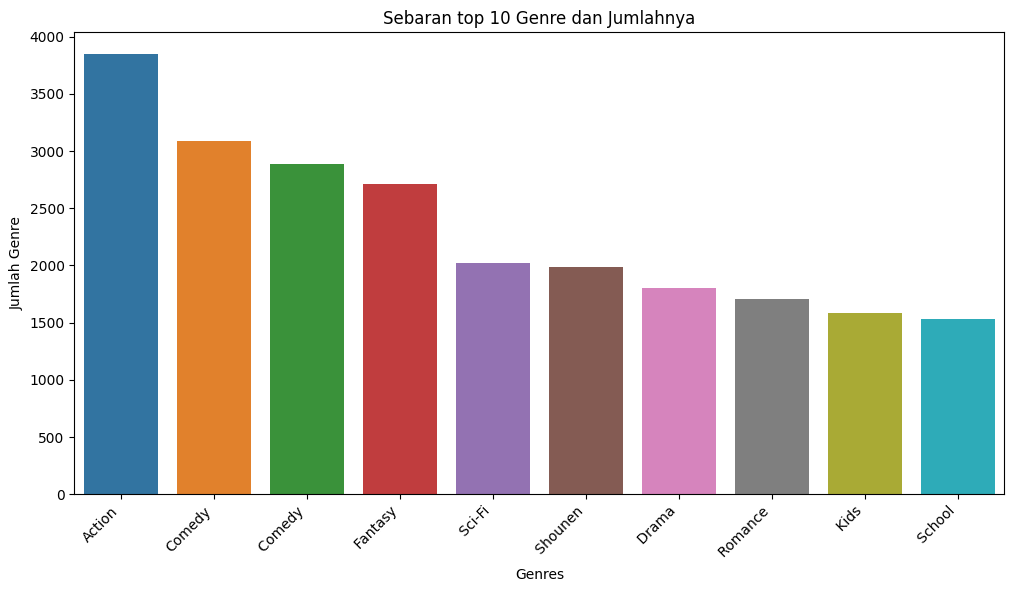

In [18]:
genre_populer =df['Genres'].str.split(',').explode()
simpan10genre = genre_populer.value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=simpan10genre.index, y= simpan10genre.values, hue= simpan10genre.index)
plt.xticks(rotation=45, ha='right')
plt.title('Sebaran top 10 Genre dan Jumlahnya')
plt.xlabel('Genres')
plt.ylabel('Jumlah Genre')
plt.show()

In [19]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [27]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def bersihkan_teks(teks):
    if pd.isnull(teks):
        return ''
    teks = teks.lower()
    teks = re.sub(r'[^a-z0-9\s]', '', teks)
    kata_kata =teks.split()
    kata_bersih = [lemmatizer.lemmatize(kata) for kata in kata_kata if kata not in stop_words]
    return " ".join(kata_bersih)

df['sypnopsis_clear'] = df['sypnopsis'].apply(bersihkan_teks)

print('Sebelum di Bersihkan: ', df['sypnopsis'].iloc[0][:100],'...')
print('Sesudah di Bersihkan: ', df['sypnopsis_clear'].iloc[0][:100],'...')

Sebelum di Bersihkan:  In the year 2071, humanity has colonized several of the planets and moons of the solar system leavin ...
Sesudah di Bersihkan:  year 2071 humanity colonized several planet moon solar system leaving uninhabitable surface planet e ...


In [32]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['sypnopsis_clear'])

print("Ukuran Matriks Tfidf: ", tfidf_matrix.shape)

cosine_sim = cosine_similarity(tfidf_matrix)


print('Ukuran Matriks Kesamaan: ', cosine_sim.shape)

Ukuran Matriks Tfidf:  (16206, 49784)
Ukuran Matriks Kesamaan:  (16206, 16206)


In [52]:
df = df.reset_index(drop=True)
indices = pd.Series(df.index, index=df['Name']).drop_duplicates()

def dapatkan_rekomendasi(judul, kemiripan =cosine_sim):
    if judul not in indices:
        print(f'Maaf. {judul} yang Anda cari tidak dapat ditemukan. Periksa kembali ejaan katanya')
    else:
        idx = indices[judul]
        skor_kemiripan = list(enumerate(kemiripan[idx]))
        skor_kemiripan = sorted(skor_kemiripan, key=lambda x: x[1], reverse= True)
        lima_teratas = skor_kemiripan[1:6]
        index_anime = [i[0] for i in lima_teratas]
    
        print(f"Berikut adalah rekomendasi judul yang mirip dengan judul {judul} yang kamu berikan:")
        print('-' * 50)
        return df[['Name', 'Genres']].iloc[index_anime]
    

In [57]:
dapatkan_rekomendasi('Monster')

Berikut adalah rekomendasi judul yang mirip dengan judul Monster yang kamu berikan:
--------------------------------------------------


,Name,Genres
854,Astro Boy: Tetsuwan Atom,"Action, Sci-Fi, Adventure, Super Power, Kids, ..."
6867,Tetsuwan Atom: Atom Tanjou no Himitsu,"Drama, Mecha, Sci-Fi"
3810,Jetter Mars,"Action, Drama, Mecha, Sci-Fi"
5052,Junod,"Historical, Drama"
7079,Doctor Chichibuyama,"Ecchi, Parody, Seinen"
